In [13]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import smarts_cerebellum.globals as gl

In [14]:
regions = ['M1L', 'M2L', 'M3L', 'M4L', 'M1R', 'M2R','M3R', 'M4R']
#regions = ['M1R', 'M1L']

cst_wm = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_WM', 'summary_MNISymC_CST_WM_mod.tsv'), sep = '\t')
cerebel_gm = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_GM', 'summary_MNISymC_Nettekoven_2024_GM_mod.tsv'), sep = '\t')

# just patients
cst_wm = cst_wm[cst_wm.isPatient == 1]
cerebel_gm = cerebel_gm[cerebel_gm.isPatient == 1]

cerebel_gm = cerebel_gm[cerebel_gm.regionname.isin(regions)]

cst_wm['hemisphere'] = cst_wm.regionname.str[0].astype(str).str.upper()
cerebel_gm['hemisphere'] = cerebel_gm.regionname.str[2]

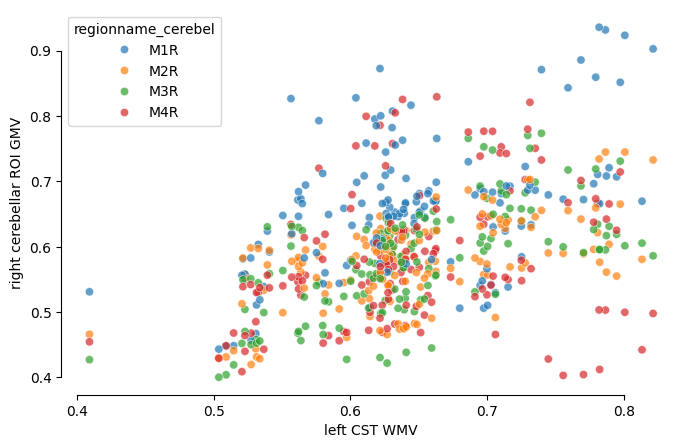

In [18]:
left_cst = cst_wm[cst_wm.hemisphere == 'L'] # contralesional CST
right_cerebel = cerebel_gm[cerebel_gm.hemisphere == 'R'] # ipsilesional cerebellum
left_df = pd.merge(left_cst, right_cerebel, on = ['subj_id', 'Week'], suffixes = ('_cst', '_cerebel'))

fig, ax = plt.subplots(figsize = (8,5))
sns.scatterplot(x = left_df['mean_cst'], y=left_df['mean_cerebel'], hue = left_df['regionname_cerebel'], alpha = .7, ax = ax)

plt.xlabel("left CST WMV")
plt.ylabel("right cerebellar ROI GMV")

sns.despine(trim = True)
plt.show()

In [16]:
left_df[['Week', 'subj_id', 'mean_cst', 'mean_cerebel', 'regionname_cerebel', 'regionname_cst']].head(10)

,Week,subj_id,mean_cst,mean_cerebel,regionname_cerebel,regionname_cst
0,0,CU_2310,0.789184,0.720776,M1R,left_CST
1,0,CU_2310,0.789184,0.603668,M2R,left_CST
2,0,CU_2310,0.789184,0.631295,M3R,left_CST
3,0,CU_2310,0.789184,0.665495,M4R,left_CST
4,4,CU_2310,0.780774,0.710625,M1R,left_CST
5,4,CU_2310,0.780774,0.621494,M2R,left_CST
6,4,CU_2310,0.780774,0.634436,M3R,left_CST
7,4,CU_2310,0.780774,0.666280,M4R,left_CST
8,12,CU_2310,0.787223,0.708201,M1R,left_CST
9,12,CU_2310,0.787223,0.561088,M2R,left_CST


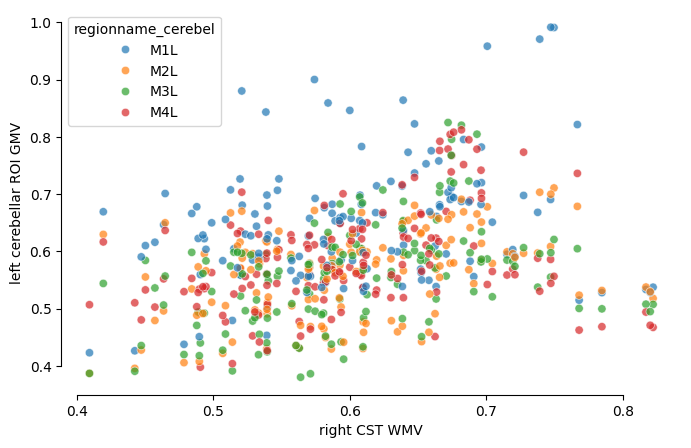

In [19]:
right_cst = cst_wm[cst_wm.hemisphere == 'R'] # ipsilesional CST
left_cerebel = cerebel_gm[cerebel_gm.hemisphere == 'L'] # contralesional cerebellum
right_df = pd.merge(right_cst, left_cerebel, on = ['subj_id', 'Week'], suffixes = ('_cst', '_cerebel'))

fig, ax = plt.subplots(figsize = (8,5))
sns.scatterplot(x = right_df['mean_cst'], y=right_df['mean_cerebel'], hue = right_df['regionname_cerebel'], alpha = .7, ax = ax)

plt.xlabel("right CST WMV")
plt.ylabel("left cerebellar ROI GMV")

sns.despine(trim = True)
plt.show()